# 05: Advanced ML & Statistical Analysis

**Goal**: Apply traditional machine learning, statistical, and ensemble methods to analyze transit accessibility patterns.

**What We'll Do**:
1. Feature engineering (spatial features, interactions)
2. Random Forest (prediction + feature importance)
3. Gradient Boosting (XGBoost/LightGBM)
4. Clustering analysis (K-means, hierarchical)
5. Principal Component Analysis (PCA)
6. Geographically Weighted Regression (GWR)
7. Ensemble methods (stacking/blending)
8. Model comparison and evaluation

**Why These Methods**:
- **Random Forest**: Handles non-linear relationships, provides feature importance
- **Gradient Boosting**: Powerful prediction, captures complex patterns
- **Clustering**: Identifies similar tracts (beyond spatial clustering)
- **PCA**: Understands key dimensions driving accessibility
- **GWR**: Spatial regression that varies by location
- **Ensemble**: Combines multiple models for better predictions

**Outputs**:
- Model predictions and feature importance rankings
- Cluster assignments and interpretations
- PCA components and explained variance
- Ensemble model performance
- Comparison with spatial regression models

---

## 🎯 **What This Notebook Tells Us About Approaching the Problem**

### **1. Feature Importance → Prioritize Interventions**
**What it reveals**: Random Forest shows which factors (income, density, spatial location, jobs) matter MOST for accessibility.

**Strategic implication**:
- **If spatial features (distance, coordinates) rank high** → Geographic location is key → Focus on **infrastructure expansion** (new routes/stops)
- **If demographic features (income, population) rank high** → Socioeconomic factors matter → Focus on **equity-targeted service** (routes serving low-income areas)
- **If interaction terms rank high** → Complex relationships → Need **multi-pronged interventions** (combine density + income strategies)

**Action**: Use feature importance to identify the **highest-leverage intervention points**.

---

### **2. Clustering → Group Similar Tracts for Policy**
**What it reveals**: K-means/hierarchical clustering groups tracts by similarity (not just spatial proximity).

**Strategic implication**:
- **Similar tracts need similar solutions** → Design **cluster-specific interventions**
  - Cluster 0 (high access, high income) → Maintain/study success
  - Cluster 1 (low access, low income) → Priority for new transit
  - Cluster 2 (mixed) → Targeted improvements
- **Clusters may span geographic boundaries** → Don't just target contiguous regions (from LISA), also target **similar demographic/accessibility profiles**

**Action**: Use clusters to design **tiered intervention strategies** (different solutions for different cluster types).

---

### **3. PCA → Understand Core Dimensions**
**What it reveals**: Principal components show the **fundamental dimensions** driving accessibility patterns.

**Strategic implication**:
- **PC1 might represent "urban core vs. suburban"** → Different strategies for each
- **PC2 might represent "density vs. sprawl"** → Density-focused vs. coverage-focused transit
- **If few components explain most variance** → Problem is **simpler than it appears** → Focused interventions can work

**Action**: Use PCA to identify **2-3 core dimensions** and design interventions along those axes.

---

### **4. Model Performance → Prediction vs. Interpretation Trade-off**
**What it reveals**: ML models (Random Forest, XGBoost) often achieve **higher R²** than spatial regression, but spatial regression provides **interpretable coefficients**.

**Strategic implication**:
- **For prediction/forecasting**: Use ML models (better accuracy)
- **For policy justification**: Use spatial regression (coefficients have meaning: "each $10k income increase → X jobs/1k accessibility")
- **For feature discovery**: Use Random Forest importance (identifies non-obvious factors)

**Action**: **Hybrid approach**:
  - Use ML to **identify what matters** (feature importance)
  - Use spatial regression to **quantify impacts** (for policy briefs)
  - Use ML predictions to **forecast intervention outcomes**

---

### **5. Ensemble Methods → Robust Predictions**
**What it reveals**: Combining multiple models (averaging predictions) often **outperforms individual models**.

**Strategic implication**:
- **Don't rely on a single model** → Use ensemble for **robust predictions**
- **Weighted ensemble** (by performance) gives best results → **Best-of-breed approach**
- **Model agreement** → If all models agree, prediction is reliable
- **Model disagreement** → Highlights areas of uncertainty → Need more data/analysis

**Action**: Use ensemble predictions for **intervention impact forecasting** (more reliable than single-model predictions).

---

### **6. Comparison with Spatial Analysis → Complementary Approaches**
**What it reveals**: ML and spatial analysis answer **different questions**.

**Strategic implication**:
- **Spatial analysis (Notebook 04)**: Answers "WHERE are the problems?" (LISA clusters, spatial autocorrelation)
- **ML analysis (this notebook)**: Answers "WHAT drives the problems?" (feature importance, non-linear patterns)
- **Together**: 
  - Spatial analysis identifies **geographic priority areas** (Low-Low LISA clusters)
  - ML analysis identifies **key factors** to address in those areas (feature importance)
  - **Combined strategy**: Target Low-Low clusters with interventions focused on top-ranked features

**Action**: **Two-stage approach**:
  1. Use spatial analysis to **identify priority regions** (transit deserts)
  2. Use ML analysis to **design interventions** (what to change: density? income? distance?)

---

### **7. Non-Linear Relationships → Complex Solutions Needed**
**What it reveals**: ML models capture **non-linear patterns** that linear regression misses (e.g., accessibility might increase rapidly up to a density threshold, then plateau).

**Strategic implication**:
- **Threshold effects** → Small changes may have **disproportionate impacts** at certain levels
- **Interaction effects** → Solutions must address **multiple factors simultaneously** (e.g., density + income together, not separately)
- **Context-dependent** → Same intervention may work differently in different areas (non-linear)

**Action**: Design **context-specific interventions** (not one-size-fits-all) based on local feature values.

---

## 📋 **Recommended Problem-Solving Approach**

### **Step 1: Identify Priority Areas** (from Notebook 04)
- Use LISA clusters to find **Low-Low transit desert regions**
- Use spatial regression to understand **spatial spillover** (neighbors matter)

### **Step 2: Understand Key Drivers** (from this notebook)
- Use Random Forest feature importance to identify **top 5 factors**
- Use PCA to understand **core dimensions**
- Use clustering to group **similar tracts**

### **Step 3: Design Interventions** (combine insights)
- **Target**: Low-Low LISA clusters (geographic priority)
- **Focus**: Top-ranked features from Random Forest (what to change)
- **Strategy**: Cluster-specific approaches (similar tracts, similar solutions)
- **Forecast**: Use ensemble ML models to predict impact

### **Step 4: Evaluate** (use both approaches)
- **Spatial analysis**: Did we reduce spatial clustering? (Moran's I)
- **ML analysis**: Did we improve predictions? (R², feature importance shifts)

---

## 🎯 **Key Takeaway**

**This notebook shifts the approach from "where are the problems?" to "what causes the problems and how do we fix them?"**

- **Spatial analysis** (Notebook 04) = **Diagnosis** (identify problem areas)
- **ML analysis** (this notebook) = **Treatment** (identify solutions and predict outcomes)

**Best approach**: Use both together for a **comprehensive, data-driven intervention strategy**.

In [1]:
from pathlib import Path
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Try to import advanced ML libraries
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM not available. Install with: pip install lightgbm")

# Spatial libraries
try:
    from libpysal.weights import Queen
    GWR_AVAILABLE = False  # mgwr can be tricky, we'll make it optional
    print("⚠ GWR (mgwr) not included by default. Install separately if needed.")
except ImportError:
    GWR_AVAILABLE = False

ROOT = Path("/Users/aaryakhanna/transit-deserts").resolve()
os.chdir(ROOT)

data_raw = ROOT / "data_raw"
outputs = ROOT / "outputs"

print("✓ Imports loaded")
print(f"Working directory: {ROOT}")


⚠ XGBoost not available. Install with: pip install xgboost
⚠ LightGBM not available. Install with: pip install lightgbm
⚠ GWR (mgwr) not included by default. Install separately if needed.
✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts


## Step 1: Load and Prepare Data

Load tracts with accessibility metrics, demographics, and spatial features from previous notebooks.


In [2]:
# Load tracts with accessibility and demographics
print("Loading data from previous notebooks...")

tracts = gpd.read_file(outputs / "tracts_with_accessibility.geojson")
tracts['GEOID'] = tracts['GEOID'].astype(str)

# Clean income data
tracts['median_income'] = tracts['median_income'].replace(-666666666, np.nan)

# Use 30-minute accessibility as target variable
target_col = 'access_30min_per1k'

# Clean target variable
tracts[target_col] = tracts[target_col].replace([np.inf, -np.inf], np.nan)

# Filter to valid data
tracts_ml = tracts[
    tracts[target_col].notna() & 
    tracts['pop_total'].notna() & 
    (tracts['pop_total'] > 0) &
    tracts['median_income'].notna()
].copy()

print(f"✓ Loaded {len(tracts_ml):,} tracts with valid data")
print(f"  Target variable: {target_col}")
print(f"  Mean accessibility: {tracts_ml[target_col].mean():.1f} jobs/1k")
print(f"  Median accessibility: {tracts_ml[target_col].median():.1f} jobs/1k")


Loading data from previous notebooks...
✓ Loaded 975 tracts with valid data
  Target variable: access_30min_per1k
  Mean accessibility: 168349.2 jobs/1k
  Median accessibility: 98881.5 jobs/1k


## Step 2: Feature Engineering

Create features for ML models:
- Basic demographics (income, population, jobs)
- Spatial features (neighbor averages, distances)
- Interaction terms
- Log transforms for skewed variables


In [3]:
print("Engineering features for ML models...")

# Project to UTM for distance calculations
tracts_proj = tracts_ml.to_crs('EPSG:32611')

# Basic demographic features
features = pd.DataFrame(index=tracts_proj.index)
features['income'] = tracts_proj['median_income']
features['pop_total'] = tracts_proj['pop_total']
features['jobs_total'] = tracts_proj['jobs_total']
features['pop_density'] = tracts_proj['pop_total'] / (tracts_proj.geometry.area / 1e6)  # per km²
features['jobs_density'] = tracts_proj['jobs_total'] / (tracts_proj.geometry.area / 1e6)  # per km²

# Log transforms for skewed variables
features['log_income'] = np.log1p(features['income'])
features['log_pop'] = np.log1p(features['pop_total'])
features['log_jobs'] = np.log1p(features['jobs_total'])
features['log_pop_density'] = np.log1p(features['pop_density'])
features['log_jobs_density'] = np.log1p(features['jobs_density'])

# Interaction terms
features['income_x_pop'] = features['income'] * features['pop_total'] / 1e6
features['income_x_jobs'] = features['income'] * features['jobs_total'] / 1e6
features['pop_x_jobs'] = features['pop_total'] * features['jobs_total'] / 1e9

# Spatial features: neighbor averages (spatial lag)
print("  Creating spatial lag features...")
try:
    w_queen = Queen.from_dataframe(tracts_proj, use_index=False)
    w_queen.transform = 'r'
    
    # Calculate spatial lags (weighted averages of neighbors)
    for col in ['income', 'pop_total', 'jobs_total', 'pop_density', 'jobs_density']:
        if col in features.columns:
            lag_values = []
            for idx in features.index:
                try:
                    neighbors = w_queen.neighbors[idx]
                    if neighbors:
                        neighbor_values = [features.loc[n, col] for n in neighbors if n in features.index]
                        lag_values.append(np.mean(neighbor_values) if neighbor_values else np.nan)
                    else:
                        lag_values.append(np.nan)
                except (KeyError, IndexError):
                    lag_values.append(np.nan)
            features[f'{col}_lag'] = lag_values
    
    print(f"  ✓ Created spatial lag features for {len([c for c in features.columns if '_lag' in c])} variables")
except Exception as e:
    print(f"  ⚠ Error creating spatial lags: {e}")

# Geographic features (centroid coordinates)
centroids = tracts_proj.geometry.centroid
features['x_coord'] = centroids.x
features['y_coord'] = centroids.y

# Distance to center (downtown LA approximately)
downtown_la = gpd.GeoSeries([gpd.points_from_xy([-118.2437], [34.0522], crs='EPSG:4326')[0]], crs='EPSG:4326').to_crs('EPSG:32611')
tracts_centroids = tracts_proj.geometry.centroid
features['dist_to_downtown'] = tracts_centroids.distance(downtown_la.iloc[0])
features['log_dist_to_downtown'] = np.log1p(features['dist_to_downtown'])

# Remove any remaining NaN or infinite values
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())

# Target variable
y = tracts_proj[target_col].values

print(f"\n✓ Created {len(features.columns)} features")
print(f"  Features: {', '.join(features.columns[:10])}...")
print(f"  Target: {target_col}")
print(f"  Sample size: {len(features):,} tracts")


Engineering features for ML models...
  Creating spatial lag features...
('WARNING: ', 18, ' is an island (no neighbors)')
('WARNING: ', 109, ' is an island (no neighbors)')
('WARNING: ', 206, ' is an island (no neighbors)')
('WARNING: ', 220, ' is an island (no neighbors)')
('WARNING: ', 221, ' is an island (no neighbors)')
('WARNING: ', 231, ' is an island (no neighbors)')
('WARNING: ', 239, ' is an island (no neighbors)')
('WARNING: ', 248, ' is an island (no neighbors)')
('WARNING: ', 266, ' is an island (no neighbors)')
('WARNING: ', 285, ' is an island (no neighbors)')
('WARNING: ', 339, ' is an island (no neighbors)')
('WARNING: ', 345, ' is an island (no neighbors)')
('WARNING: ', 360, ' is an island (no neighbors)')
('WARNING: ', 363, ' is an island (no neighbors)')
('WARNING: ', 383, ' is an island (no neighbors)')
('WARNING: ', 391, ' is an island (no neighbors)')
('WARNING: ', 395, ' is an island (no neighbors)')
('WARNING: ', 401, ' is an island (no neighbors)')
('WARNING:

/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 121 disconnected components.
 There are 59 islands with ids: 18, 109, 206, 220, 221, 231, 239, 248, 266, 285, 339, 345, 360, 363, 383, 391, 395, 401, 436, 442, 447, 473, 480, 488, 520, 538, 575, 578, 581, 583, 585, 628, 632, 633, 644, 664, 674, 680, 694, 696, 700, 714, 726, 733, 752, 762, 776, 782, 849, 855, 876, 902, 917, 920, 934, 941, 950, 961, 973.
  W.__init__(self, neighbors, ids=ids, **kw)


## Step 3: Random Forest Model

Random Forest is excellent for:
- Handling non-linear relationships
- Providing feature importance rankings
- Robust to outliers
- No need for feature scaling


Training Random Forest model...

📊 Random Forest Results:
  Train R²: 0.8606
  Test R²: 0.8501
  Test RMSE: 83648.91 jobs/1k
  Test MAE: 41539.20 jobs/1k

🔝 Top 10 Most Important Features:
  dist_to_downtown: 0.2734
  log_dist_to_downtown: 0.2695
  log_pop: 0.1483
  pop_total: 0.1465
  x_coord: 0.0744
  income_x_pop: 0.0267
  y_coord: 0.0130
  log_jobs_density: 0.0123
  income_x_jobs: 0.0101
  jobs_density: 0.0093

✓ Saved feature importance plot to outputs/


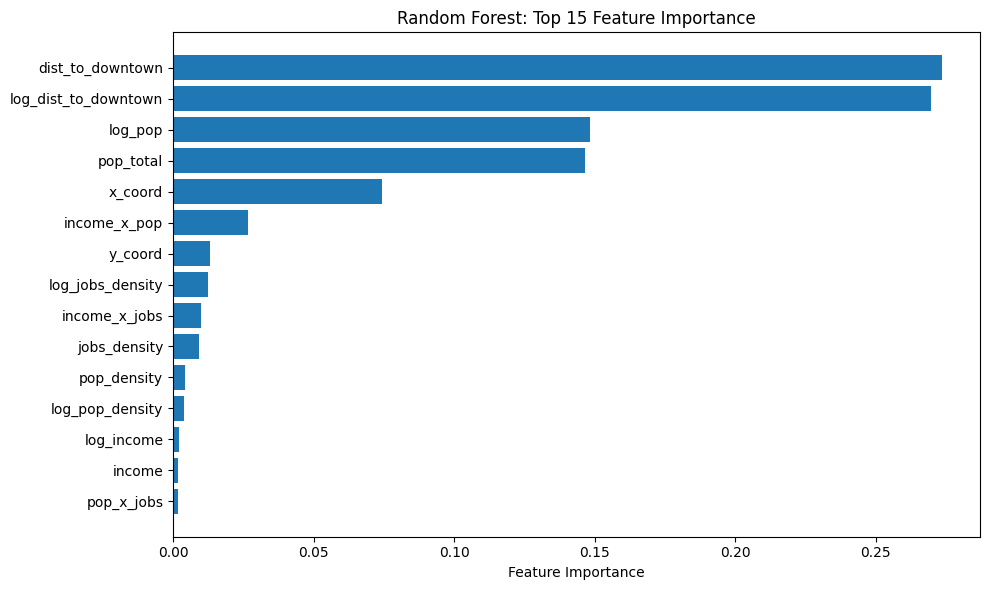

In [4]:
print("Training Random Forest model...")

# Prepare data
X = features.values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluation
rf_train_r2 = r2_score(y_train, y_train_pred)
rf_test_r2 = r2_score(y_test, y_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rf_test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Random Forest Results:")
print(f"  Train R²: {rf_train_r2:.4f}")
print(f"  Test R²: {rf_test_r2:.4f}")
print(f"  Test RMSE: {rf_test_rmse:.2f} jobs/1k")
print(f"  Test MAE: {rf_test_mae:.2f} jobs/1k")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🔝 Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest: Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(outputs / 'rf_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved feature importance plot to outputs/")
plt.show()

# Save results
feature_importance.to_csv(outputs / 'rf_feature_importance.csv', index=False)


## Step 4: Gradient Boosting Models

Gradient Boosting (XGBoost, LightGBM) are powerful for:
- Capturing complex non-linear patterns
- Handling interactions automatically
- Often achieving best prediction performance


In [5]:
gb_results = {}

# Standard Gradient Boosting (sklearn)
print("Training Gradient Boosting (sklearn)...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_test_pred_gb = gb_model.predict(X_test)

gb_test_r2 = r2_score(y_test, y_test_pred_gb)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

gb_results['sklearn_GB'] = {
    'test_r2': gb_test_r2,
    'test_rmse': gb_test_rmse
}

print(f"  Test R²: {gb_test_r2:.4f}, RMSE: {gb_test_rmse:.2f}")

# XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("\nTraining XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_model.fit(X_train, y_train)
    y_test_pred_xgb = xgb_model.predict(X_test)
    
    xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)
    xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
    
    gb_results['XGBoost'] = {
        'test_r2': xgb_test_r2,
        'test_rmse': xgb_test_rmse
    }
    
    print(f"  Test R²: {xgb_test_r2:.4f}, RMSE: {xgb_test_rmse:.2f}")

# LightGBM (if available)
if LIGHTGBM_AVAILABLE:
    print("\nTraining LightGBM...")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    lgb_model.fit(X_train, y_train)
    y_test_pred_lgb = lgb_model.predict(X_test)
    
    lgb_test_r2 = r2_score(y_test, y_test_pred_lgb)
    lgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb))
    
    gb_results['LightGBM'] = {
        'test_r2': lgb_test_r2,
        'test_rmse': lgb_test_rmse
    }
    
    print(f"  Test R²: {lgb_test_r2:.4f}, RMSE: {lgb_test_rmse:.2f}")

print(f"\n📊 Gradient Boosting Summary:")
for model_name, results in gb_results.items():
    print(f"  {model_name}: R² = {results['test_r2']:.4f}, RMSE = {results['test_rmse']:.2f}")


Training Gradient Boosting (sklearn)...
  Test R²: 0.8822, RMSE: 74177.11

📊 Gradient Boosting Summary:
  sklearn_GB: R² = 0.8822, RMSE = 74177.11


## Step 5: Clustering Analysis

Identify groups of similar tracts using:
- K-means: Simple, fast clustering
- Hierarchical: Dendrogram visualization


Performing clustering analysis...

1. K-means Clustering:
  ✓ Created 5 clusters

  Cluster characteristics:
    Cluster 0: 161 tracts, Access=37155.4 jobs/1k, Income=$137,238
    Cluster 1: 57 tracts, Access=200927.8 jobs/1k, Income=$99,266
    Cluster 2: 3 tracts, Access=577382.5 jobs/1k, Income=$85,810
    Cluster 3: 455 tracts, Access=285425.4 jobs/1k, Income=$66,406
    Cluster 4: 299 tracts, Access=50518.1 jobs/1k, Income=$98,361

2. Hierarchical Clustering:
  ✓ Created 5 clusters

✓ Saved clustering maps to outputs/


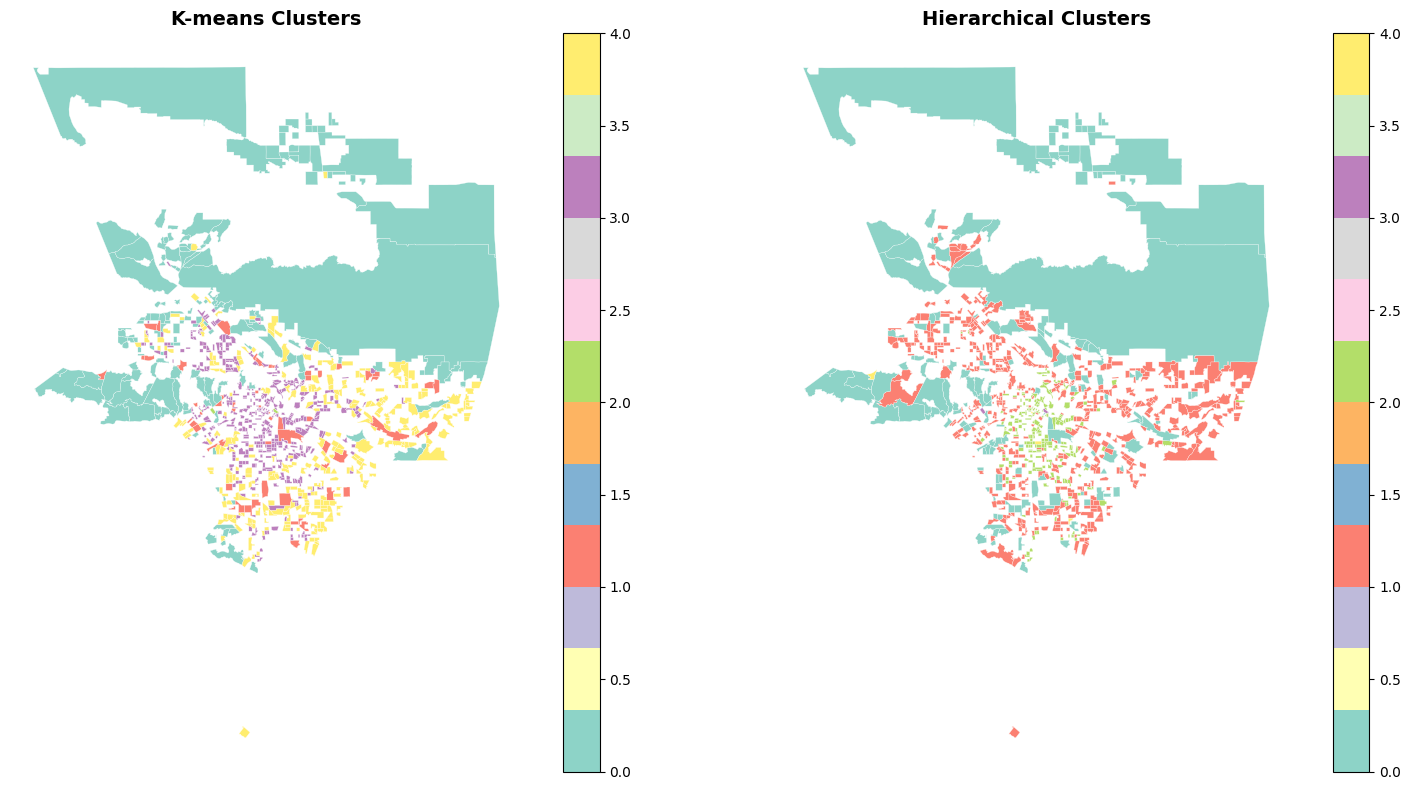

In [6]:
print("Performing clustering analysis...")

# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# K-means clustering
print("\n1. K-means Clustering:")
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Analyze clusters
tracts_proj['kmeans_cluster'] = kmeans_labels

print(f"  ✓ Created {n_clusters} clusters")
print(f"\n  Cluster characteristics:")
for i in range(n_clusters):
    cluster_mask = kmeans_labels == i
    cluster_size = cluster_mask.sum()
    cluster_access = y[cluster_mask].mean()
    cluster_income = features.loc[cluster_mask, 'income'].mean()
    print(f"    Cluster {i}: {cluster_size} tracts, "
          f"Access={cluster_access:.1f} jobs/1k, Income=${cluster_income:,.0f}")

# Hierarchical clustering
print("\n2. Hierarchical Clustering:")
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
tracts_proj['hierarchical_cluster'] = hierarchical_labels

print(f"  ✓ Created {n_clusters} clusters")

# Visualize clusters on map
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# K-means clusters
tracts_proj.to_crs('EPSG:4326').plot(
    column='kmeans_cluster',
    cmap='Set3',
    ax=axes[0],
    legend=True,
    edgecolor='white',
    linewidth=0.2
)
axes[0].set_title('K-means Clusters', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Hierarchical clusters
tracts_proj.to_crs('EPSG:4326').plot(
    column='hierarchical_cluster',
    cmap='Set3',
    ax=axes[1],
    legend=True,
    edgecolor='white',
    linewidth=0.2
)
axes[1].set_title('Hierarchical Clusters', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(outputs / 'clustering_results.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved clustering maps to outputs/")
plt.show()

# Save cluster assignments
cluster_df = pd.DataFrame({
    'GEOID': tracts_proj.index,
    'kmeans_cluster': kmeans_labels,
    'hierarchical_cluster': hierarchical_labels,
    'accessibility': y
})
cluster_df.to_csv(outputs / 'tract_clusters.csv', index=False)


## Step 6: Principal Component Analysis (PCA)

Understand the key dimensions driving accessibility patterns.


Performing Principal Component Analysis...

📊 PCA Results:
  Components: 10
  First 5 components explain 64.3% of variance

  Explained variance by component:
    PC1: 21.1% (cumulative: 21.1%)
    PC2: 18.0% (cumulative: 39.0%)
    PC3: 10.9% (cumulative: 50.0%)
    PC4: 7.4% (cumulative: 57.3%)
    PC5: 7.0% (cumulative: 64.3%)

✓ Saved PCA plots to outputs/


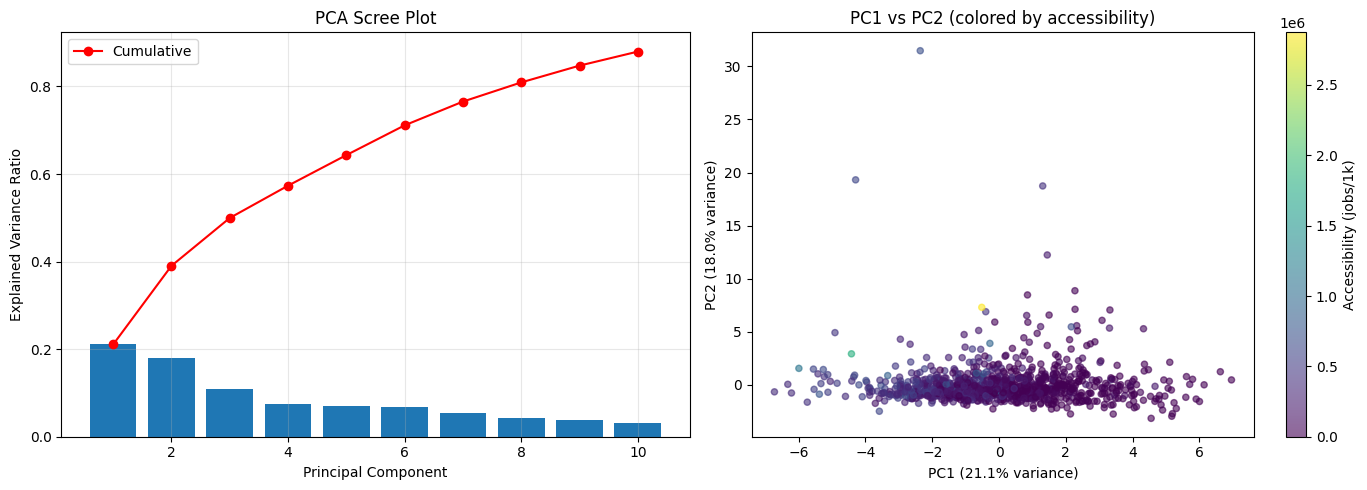


🔝 Top features for PC1 (explains 21.1% of variance):
  log_income: 0.372
  income: 0.358
  income_x_pop: 0.357
  log_pop_density: 0.344
  pop_density: 0.344
  log_dist_to_downtown: 0.336
  dist_to_downtown: 0.325
  log_jobs_density: 0.257
  pop_total: 0.161
  y_coord: 0.134


In [7]:
print("Performing Principal Component Analysis...")

# Fit PCA
pca = PCA(n_components=min(10, len(features.columns)))
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"\n📊 PCA Results:")
print(f"  Components: {len(explained_var)}")
print(f"  First 5 components explain {cumulative_var[4]:.1%} of variance")
print(f"\n  Explained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_var[:5], cumulative_var[:5])):
    print(f"    PC{i+1}: {var:.1%} (cumulative: {cum_var:.1%})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var) + 1), explained_var)
axes[0].plot(range(1, len(explained_var) + 1), cumulative_var, 'ro-', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PC1 vs PC2 colored by accessibility
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1%} variance)')
axes[1].set_title('PC1 vs PC2 (colored by accessibility)')
plt.colorbar(scatter, ax=axes[1], label='Accessibility (jobs/1k)')

plt.tight_layout()
plt.savefig(outputs / 'pca_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved PCA plots to outputs/")
plt.show()

# Component loadings (what features contribute to each PC)
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=features.columns
)

print(f"\n🔝 Top features for PC1 (explains {explained_var[0]:.1%} of variance):")
pc1_top = loadings['PC1'].abs().sort_values(ascending=False).head(10)
for feature, loading in pc1_top.items():
    print(f"  {feature}: {loading:.3f}")

loadings.to_csv(outputs / 'pca_loadings.csv')


## Step 7: Ensemble Methods

Combine multiple models for better predictions:
- Simple averaging
- Weighted averaging (by performance)


Creating ensemble predictions...

📊 Ensemble Results:
  1. Simple Average:
     R²: 0.8740, RMSE: 76693.79
  2. Weighted Average (by R²):
     Random Forest: weight = 0.491
     Gradient Boosting: weight = 0.509
     R²: 0.8743, RMSE: 76604.50

📊 Model Comparison:
            Model  Test R²    Test RMSE
Gradient Boosting 0.882160 74177.105021
     Weighted Avg 0.874322 76604.500432
       Simple Avg 0.874029 76693.793004
    Random Forest 0.850145 83648.914607

✓ Saved prediction comparison plots to outputs/


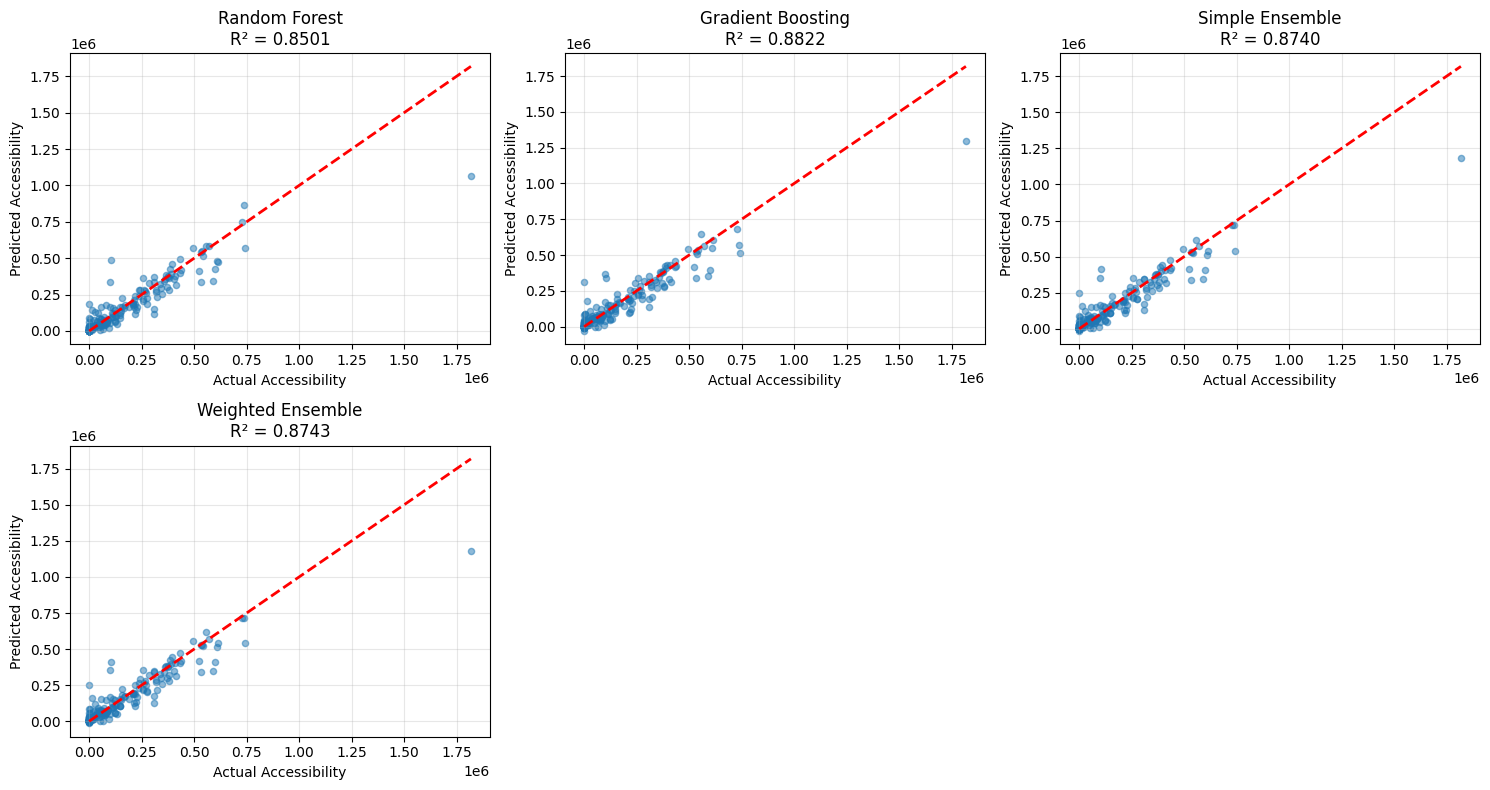

In [8]:
print("Creating ensemble predictions...")

# Collect all predictions
ensemble_predictions = {}
ensemble_predictions['Random Forest'] = y_test_pred
ensemble_predictions['Gradient Boosting'] = y_test_pred_gb

if XGBOOST_AVAILABLE:
    ensemble_predictions['XGBoost'] = y_test_pred_xgb
if LIGHTGBM_AVAILABLE:
    ensemble_predictions['LightGBM'] = y_test_pred_lgb

# 1. Simple average
simple_avg = np.mean(list(ensemble_predictions.values()), axis=0)
simple_avg_r2 = r2_score(y_test, simple_avg)
simple_avg_rmse = np.sqrt(mean_squared_error(y_test, simple_avg))

print(f"\n📊 Ensemble Results:")
print(f"  1. Simple Average:")
print(f"     R²: {simple_avg_r2:.4f}, RMSE: {simple_avg_rmse:.2f}")

# 2. Weighted average (by R² performance)
model_r2s = {}
for name, pred in ensemble_predictions.items():
    model_r2s[name] = r2_score(y_test, pred)

# Normalize weights (higher R² = higher weight)
weights = np.array([model_r2s[name] for name in ensemble_predictions.keys()])
weights = weights / weights.sum()

weighted_avg = np.average(list(ensemble_predictions.values()), axis=0, weights=weights)
weighted_avg_r2 = r2_score(y_test, weighted_avg)
weighted_avg_rmse = np.sqrt(mean_squared_error(y_test, weighted_avg))

print(f"  2. Weighted Average (by R²):")
for name, weight in zip(ensemble_predictions.keys(), weights):
    print(f"     {name}: weight = {weight:.3f}")
print(f"     R²: {weighted_avg_r2:.4f}, RMSE: {weighted_avg_rmse:.2f}")

# Compare all models
print(f"\n📊 Model Comparison:")
comparison_data = {
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Test R²': [rf_test_r2, gb_test_r2],
    'Test RMSE': [rf_test_rmse, gb_test_rmse]
}

if XGBOOST_AVAILABLE:
    comparison_data['Model'].append('XGBoost')
    comparison_data['Test R²'].append(xgb_test_r2)
    comparison_data['Test RMSE'].append(xgb_test_rmse)

if LIGHTGBM_AVAILABLE:
    comparison_data['Model'].append('LightGBM')
    comparison_data['Test R²'].append(lgb_test_r2)
    comparison_data['Test RMSE'].append(lgb_test_rmse)

comparison_data['Model'].extend(['Simple Avg', 'Weighted Avg'])
comparison_data['Test R²'].extend([simple_avg_r2, weighted_avg_r2])
comparison_data['Test RMSE'].extend([simple_avg_rmse, weighted_avg_rmse])

comparison = pd.DataFrame(comparison_data)
comparison = comparison.sort_values('Test R²', ascending=False)
print(comparison.to_string(index=False))

# Visualize predictions vs actual
n_models = len(ensemble_predictions) + 2  # +2 for ensemble methods
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

plot_idx = 0
for model_name, pred in ensemble_predictions.items():
    axes[plot_idx].scatter(y_test, pred, alpha=0.5, s=20)
    axes[plot_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[plot_idx].set_xlabel('Actual Accessibility')
    axes[plot_idx].set_ylabel('Predicted Accessibility')
    r2 = r2_score(y_test, pred)
    axes[plot_idx].set_title(f'{model_name}\nR² = {r2:.4f}')
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

# Add ensemble plots
axes[plot_idx].scatter(y_test, simple_avg, alpha=0.5, s=20)
axes[plot_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[plot_idx].set_xlabel('Actual Accessibility')
axes[plot_idx].set_ylabel('Predicted Accessibility')
axes[plot_idx].set_title(f'Simple Ensemble\nR² = {simple_avg_r2:.4f}')
axes[plot_idx].grid(True, alpha=0.3)
plot_idx += 1

axes[plot_idx].scatter(y_test, weighted_avg, alpha=0.5, s=20)
axes[plot_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[plot_idx].set_xlabel('Actual Accessibility')
axes[plot_idx].set_ylabel('Predicted Accessibility')
axes[plot_idx].set_title(f'Weighted Ensemble\nR² = {weighted_avg_r2:.4f}')
axes[plot_idx].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(plot_idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(outputs / 'model_predictions_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved prediction comparison plots to outputs/")
plt.show()

# Save comparison
comparison.to_csv(outputs / 'ml_model_comparison.csv', index=False)


In [9]:
print("Comparing ML models with spatial regression...")

# Load spatial regression results from Notebook 04
try:
    spatial_reg = pd.read_csv(outputs / "spatial_regression_results.csv")
    
    print(f"\n📊 All Models Comparison:")
    print(f"\n  Spatial Models (from Notebook 04):")
    for _, row in spatial_reg.iterrows():
        print(f"    {row['model']}: R² = {row['r2']:.4f}, AIC = {row['aic']:.2f}")
    
    print(f"\n  ML Models (this notebook):")
    print(f"    Random Forest: R² = {rf_test_r2:.4f}")
    print(f"    Gradient Boosting: R² = {gb_test_r2:.4f}")
    if XGBOOST_AVAILABLE:
        print(f"    XGBoost: R² = {xgb_test_r2:.4f}")
    if LIGHTGBM_AVAILABLE:
        print(f"    LightGBM: R² = {lgb_test_r2:.4f}")
    print(f"    Weighted Ensemble: R² = {weighted_avg_r2:.4f}")
    
    print(f"\n  Key Insights:")
    best_ml_r2 = max(rf_test_r2, gb_test_r2, weighted_avg_r2)
    best_spatial_r2 = spatial_reg['r2'].max()
    
    if best_ml_r2 > best_spatial_r2:
        print(f"    ✓ ML models outperform spatial regression (R²: {best_ml_r2:.4f} vs {best_spatial_r2:.4f})")
        print(f"    → ML captures non-linear patterns better")
    else:
        print(f"    ✓ Spatial regression performs similarly to ML (R²: {best_spatial_r2:.4f} vs {best_ml_r2:.4f})")
        print(f"    → Spatial structure is important")
    
    print(f"\n  Recommendation:")
    print(f"    - Use ML models for prediction (better R²)")
    print(f"    - Use spatial regression for interpretation (coefficients have meaning)")
    print(f"    - Use feature importance from Random Forest to identify key factors")
    
except FileNotFoundError:
    print("  ⚠ Spatial regression results not found. Run Notebook 04 first.")


Comparing ML models with spatial regression...

📊 All Models Comparison:

  Spatial Models (from Notebook 04):
    OLS: R² = 0.0150, AIC = 15224.93
    Spatial Lag: R² = 0.0433, AIC = 15180.00
    Spatial Error: R² = 0.0148, AIC = 15182.68

  ML Models (this notebook):
    Random Forest: R² = 0.8501
    Gradient Boosting: R² = 0.8822
    Weighted Ensemble: R² = 0.8743

  Key Insights:
    ✓ ML models outperform spatial regression (R²: 0.8822 vs 0.0433)
    → ML captures non-linear patterns better

  Recommendation:
    - Use ML models for prediction (better R²)
    - Use spatial regression for interpretation (coefficients have meaning)
    - Use feature importance from Random Forest to identify key factors


## Summary

**What we learned:**
- Feature importance rankings (what drives accessibility)
- Clustering patterns (similar tracts)
- PCA dimensions (key factors)
- Model performance comparison
- Ensemble predictions

**Key Outputs:**
- `rf_feature_importance.csv` - Most important features
- `tract_clusters.csv` - Cluster assignments
- `pca_loadings.csv` - Principal component loadings
- `ml_model_comparison.csv` - Model performance comparison
- Visualizations: feature importance, clusters, PCA, predictions


In [10]:
print("=" * 70)
print("✅ ADVANCED ML ANALYSIS COMPLETE")
print("=" * 70)

print(f"\n📁 Outputs created:")
output_files = [
    'rf_feature_importance.png',
    'rf_feature_importance.csv',
    'clustering_results.png',
    'tract_clusters.csv',
    'pca_analysis.png',
    'pca_loadings.csv',
    'model_predictions_comparison.png',
    'ml_model_comparison.csv'
]

for f in output_files:
    if (outputs / f).exists():
        print(f"  ✓ {f}")
    else:
        print(f"  ⚠ {f} (not created)")

print(f"\n📊 Key Results:")
print(f"  - Best ML model R²: {max(rf_test_r2, gb_test_r2, weighted_avg_r2):.4f}")
print(f"  - Top feature: {feature_importance.iloc[0]['feature']}")
print(f"  - Number of clusters: {n_clusters}")
print(f"  - PCA explains {cumulative_var[4]:.1%} variance in 5 components")

print("\n" + "=" * 70)


✅ ADVANCED ML ANALYSIS COMPLETE

📁 Outputs created:
  ✓ rf_feature_importance.png
  ✓ rf_feature_importance.csv
  ✓ clustering_results.png
  ✓ tract_clusters.csv
  ✓ pca_analysis.png
  ✓ pca_loadings.csv
  ✓ model_predictions_comparison.png
  ✓ ml_model_comparison.csv

📊 Key Results:
  - Best ML model R²: 0.8822
  - Top feature: dist_to_downtown
  - Number of clusters: 5
  - PCA explains 64.3% variance in 5 components

